# 05. Política de concessão de crédito

Neste notebook, eu vou tentar transformar o score de risco criado na etapa anterior em uma política objetiva de concessão de crédito.

A política proposta combina quatro dimensões:

1. risco estimado de inadimplência em 12 meses;
2. capacidade de pagamento do cliente;
3. presença e intensidade de restritivos financeiros;
4. relacionamento do cliente com a instituição.

O objetivo não é só aprovar ou recusar a proposta, mas também sugerir um valor máximo de empréstimo compatível com o risco e com a capacidade financeira do cliente.

In [19]:
# Setup inicial do notebook.

import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
from sklearn.inspection import permutation_importance
import shap

pio.renderers.default = "notebook_connected+png"

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from concessao_credito.config import (
    PROCESSED_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    MODELS_DIR,
)

from concessao_credito.plots import (
    registrar_template_credito,
    aplicar_layout,
    salvar_figura,
)

registrar_template_credito()

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.4f}".format)

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Projeto:", PROJECT_ROOT)
print("Base processada:", PROCESSED_DIR)
print("Modelos:", MODELS_DIR)

Projeto: c:\GitHub\datascience\projetos\concessao_credito
Base processada: C:\GitHub\datascience\projetos\concessao_credito\data\processed
Modelos: C:\GitHub\datascience\projetos\concessao_credito\outputs\models


## 1. Leitura da base e do modelo de PD

Aqui eu carrego a base de modelagem com target observado em 12 meses e o modelo candidato salvo no notebook anterior.

A política será simulada inicialmente sobre a safra de teste temporal, pois ela representa melhor o comportamento esperado em concessões futuras.

In [5]:
# Leitura da base com target observável.

base_path = PROCESSED_DIR / "base_modelagem_12m.parquet"
base = pd.read_parquet(base_path)

for col in ["data_concessao", "data_nascimento", "data_abertura_conta", "data_ref_12m"]:
    if col in base.columns:
        base[col] = pd.to_datetime(base[col], errors="coerce")

# Garante variáveis derivadas, caso não estejam gravadas na base.
if "idade_concessao" not in base.columns:
    base["idade_concessao"] = (
        (base["data_concessao"] - base["data_nascimento"]).dt.days / 365.25
    )

if "tempo_conta_anos" not in base.columns:
    base["tempo_conta_anos"] = (
        (base["data_concessao"] - base["data_abertura_conta"]).dt.days / 365.25
    )

if "comprometimento_renda" not in base.columns:
    base["comprometimento_renda"] = np.where(
        base["valor_renda"] > 0,
        base["valor_parcela"] / base["valor_renda"],
        np.nan,
    )

if "restritivos_sobre_renda" not in base.columns:
    base["restritivos_sobre_renda"] = np.where(
        base["valor_renda"] > 0,
        base["valor_restritivos"] / base["valor_renda"],
        np.nan,
    )

if "id_operacao" not in base.columns:
    base["id_operacao"] = (
        base["id_cliente"].astype(str)
        + "_"
        + base["data_concessao"].dt.strftime("%Y%m%d")
    )

print("Shape da base:", base.shape)
display(base.head())

Shape da base: (19558, 30)


,id_cliente,data_concessao,valor_emprestado,valor_parcela,valor_taxa,valor_prazo,valor_renda,valor_restritivos,cat_escolaridade,flag_cliente_ativo,cod_agencia,data_nascimento,data_abertura_conta,idade_concessao,tempo_conta_anos,comprometimento_renda,restritivos_sobre_renda,id_operacao,data_ref_12m,tem_janela_12m,flag_inadimplente_12m_observado,target_inadimplente_12m,origem_target_12m,target_inadimplente_ate_12m,fx_valor_renda,fx_valor_emprestado,fx_valor_parcela,fx_comprometimento_renda,fx_valor_restritivos,fx_restritivos_sobre_renda
0,2,2020-10-02,"12,822.7800","1,119.3900",0.0358,15,"4,140.8700",5.2100,Médio Incompleto,1,89,1975-08-01,2019-12-06,45.1718,0.8241,0.2703,0.0013,2,2021-10-31,True,0.0000,0.0000,observado_no_mes_12,0.0000,"(3478.248, 5003.316]","(11630.72, 19467.92]","(1090.946, 1675.716]","(0.258, 0.416]","(4.438, 42.52]","(0.00125, 0.013]"
1,3,2020-10-01,"11,683.1500","1,540.4700",0.0357,9,"2,505.7400",0.0000,Médio Incompleto,1,61,1988-05-03,2019-10-22,32.4134,0.9446,0.6148,0.0000,3,2021-10-31,True,NaN,0.0000,sem_registro_no_mes_12_assumido_quitado,0.0000,"(1804.064, 2575.78]","(11630.72, 19467.92]","(1090.946, 1675.716]","(0.58, 0.74]","(-0.001, 4.438]","(-0.001, 0.00125]"
2,9,2020-06-05,"29,299.1400","3,143.7900",0.0412,12,"4,807.5400",15.7800,Fundamental Incompleto,0,61,1976-11-09,2018-11-23,43.5702,1.5332,0.6539,0.0033,9,2021-06-30,True,0.0000,0.0000,observado_no_mes_12,0.0000,"(3478.248, 5003.316]","(19467.92, 162511.33]","(2655.548, 23401.53]","(0.58, 0.74]","(4.438, 42.52]","(0.00125, 0.013]"
3,12,2021-04-01,"18,797.4200","2,823.7100",0.0427,8,"3,427.1200",0.0000,Sem Escolaridade,1,63,2003-04-02,2020-10-04,17.9986,0.4901,0.8239,0.0000,12,2022-04-30,True,NaN,0.0000,sem_registro_no_mes_12_assumido_quitado,0.0000,"(2575.78, 3478.248]","(11630.72, 19467.92]","(2655.548, 23401.53]","(0.74, 0.9]","(-0.001, 4.438]","(-0.001, 0.00125]"
4,15,2020-09-29,"11,975.9300","1,248.9700",0.0363,12,"1,663.7500",21.5600,Não Declarado,1,28,1985-03-25,2017-11-28,35.5154,2.8364,0.7507,0.0130,15,2021-09-30,True,0.0000,0.0000,observado_no_mes_12,0.0000,"(1199.999, 1804.064]","(11630.72, 19467.92]","(1090.946, 1675.716]","(0.74, 0.9]","(4.438, 42.52]","(0.00125, 0.013]"


In [6]:
# Carrega o modelo candidato salvo no notebook anterior.

modelo_preferido_path = MODELS_DIR / "modelo_pd_12m_gradient_boosting_optuna.joblib"

if modelo_preferido_path.exists():
    modelo_path = modelo_preferido_path
else:
    modelos_disponiveis = sorted(
        MODELS_DIR.glob("modelo_pd_12m_*.joblib"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    if not modelos_disponiveis:
        raise FileNotFoundError("Nenhum modelo de PD foi encontrado em MODELS_DIR.")

    modelo_path = modelos_disponiveis[0]

modelo_pd = joblib.load(modelo_path)

print("Modelo carregado:", modelo_path)

Modelo carregado: C:\GitHub\datascience\projetos\concessao_credito\outputs\models\modelo_pd_12m_gradient_boosting_optuna.joblib


## 2. Aplicação do score de PD

Aqui eu aplico o modelo candidato na base histórica para gerar a probabilidade estimada de inadimplência em 12 meses.

Esse score vai ser o principal insumo de risco da política de concessão.

In [7]:
target_col = "target_inadimplente_12m"

features_numericas = [
    "valor_emprestado",
    "valor_parcela",
    "valor_taxa",
    "valor_prazo",
    "valor_renda",
    "valor_restritivos",
    "idade_concessao",
    "tempo_conta_anos",
    "comprometimento_renda",
    "restritivos_sobre_renda",
]

features_categoricas = [
    "cat_escolaridade",
    "flag_cliente_ativo",
]

features_modelo = features_numericas + features_categoricas

features_faltantes = [
    col for col in features_modelo
    if col not in base.columns
]

print("Features faltantes:", features_faltantes)

if features_faltantes:
    raise ValueError("Existem features faltantes para aplicação do modelo.")

base_score = base.copy()

base_score["pd_score"] = modelo_pd.predict_proba(
    base_score[features_modelo]
)[:, 1]

display(
    base_score[
        [
            "id_operacao",
            "data_concessao",
            target_col,
            "pd_score",
            "valor_emprestado",
            "valor_parcela",
            "valor_renda",
            "comprometimento_renda",
            "valor_restritivos",
            "restritivos_sobre_renda",
        ]
    ].head()
)

Features faltantes: []


,id_operacao,data_concessao,target_inadimplente_12m,pd_score,valor_emprestado,valor_parcela,valor_renda,comprometimento_renda,valor_restritivos,restritivos_sobre_renda
0,2,2020-10-02,0.0000,0.0133,"12,822.7800","1,119.3900","4,140.8700",0.2703,5.2100,0.0013
1,3,2020-10-01,0.0000,0.0544,"11,683.1500","1,540.4700","2,505.7400",0.6148,0.0000,0.0000
2,9,2020-06-05,0.0000,0.0810,"29,299.1400","3,143.7900","4,807.5400",0.6539,15.7800,0.0033
3,12,2021-04-01,0.0000,0.3503,"18,797.4200","2,823.7100","3,427.1200",0.8239,0.0000,0.0000
4,15,2020-09-29,0.0000,0.1144,"11,975.9300","1,248.9700","1,663.7500",0.7507,21.5600,0.0130


## 3. Separação da safra de validação da política

Para avaliar a política de concessão, eu vou usar a mesma lógica temporal da modelagem: as concessões mais recentes ficam como safra de validação.

Essa etapa evita avaliar a política apenas em dados antigos e cria uma simulação mais próxima do uso real.

In [8]:
base_score = base_score.sort_values("data_concessao").reset_index(drop=True)

idx_corte = int(len(base_score) * 0.75)
data_corte = base_score.loc[idx_corte, "data_concessao"]

df_politica = base_score[
    base_score["data_concessao"] > data_corte
].copy()

print("Data de corte:", data_corte)
print("Shape da safra de validação:", df_politica.shape)

resumo_safra_politica = pd.DataFrame([
    {
        "qtd_operacoes": len(df_politica),
        "data_min": df_politica["data_concessao"].min(),
        "data_max": df_politica["data_concessao"].max(),
        "taxa_inadimplencia_observada": df_politica[target_col].mean(),
        "pd_media": df_politica["pd_score"].mean(),
        "valor_total_emprestado": df_politica["valor_emprestado"].sum(),
    }
])

display(resumo_safra_politica)

resumo_safra_politica.to_csv(
    TABLES_DIR / "politica_resumo_safra_validacao.csv",
    index=False,
    encoding="utf-8-sig",
)

Data de corte: 2021-02-02 00:00:00
Shape da safra de validação: (4862, 31)


,qtd_operacoes,data_min,data_max,taxa_inadimplencia_observada,pd_media,valor_total_emprestado
0,4862,2021-02-03,2021-07-30,0.1230,0.1237,"64,604,367.2200"


## 4. Criação das faixas de risco

Aqui eu transformo a PD estimada em faixas de risco.

Nesta primeira versão, as faixas são criadas a partir da distribuição do score na safra de validação. Depois de observar os resultados, os limites podem ser calibrados de forma mais conservadora ou mais agressiva.

In [9]:
# Limites iniciais por quantis da PD na safra de validação.

limites_pd = df_politica["pd_score"].quantile(
    [0.40, 0.60, 0.75, 0.90]
).to_dict()

limite_a = limites_pd[0.40]
limite_b = limites_pd[0.60]
limite_c = limites_pd[0.75]
limite_d = limites_pd[0.90]

print("Limites de PD por faixa:")
print("A - Baixo risco até:", limite_a)
print("B - Médio-baixo risco até:", limite_b)
print("C - Médio risco até:", limite_c)
print("D - Alto risco até:", limite_d)


def classificar_faixa_risco(pd_score):
    if pd_score <= limite_a:
        return "A - Baixo risco"
    elif pd_score <= limite_b:
        return "B - Médio-baixo risco"
    elif pd_score <= limite_c:
        return "C - Médio risco"
    elif pd_score <= limite_d:
        return "D - Alto risco"
    else:
        return "E - Muito alto risco"


df_politica["faixa_risco"] = df_politica["pd_score"].apply(
    classificar_faixa_risco
)

resumo_faixas_risco = (
    df_politica
    .groupby("faixa_risco", as_index=False)
    .agg(
        qtd_operacoes=("id_operacao", "count"),
        pd_media=("pd_score", "mean"),
        taxa_inadimplencia=("target_inadimplente_12m", "mean"),
        valor_medio_emprestado=("valor_emprestado", "mean"),
        valor_total_emprestado=("valor_emprestado", "sum"),
    )
)

resumo_faixas_risco["perc_operacoes"] = (
    resumo_faixas_risco["qtd_operacoes"] / resumo_faixas_risco["qtd_operacoes"].sum()
)

display(resumo_faixas_risco)

resumo_faixas_risco.to_csv(
    TABLES_DIR / "politica_resumo_faixas_risco.csv",
    index=False,
    encoding="utf-8-sig",
)

Limites de PD por faixa:
A - Baixo risco até: 0.042542714077584115
B - Médio-baixo risco até: 0.08228260737997997
C - Médio risco até: 0.14662307596641633
D - Alto risco até: 0.3505145739311863


,faixa_risco,qtd_operacoes,pd_media,taxa_inadimplencia,valor_medio_emprestado,valor_total_emprestado,perc_operacoes
0,A - Baixo risco,1945,0.0225,0.0108,"10,940.3853","21,279,049.3200",0.4000
1,B - Médio-baixo risco,972,0.0607,0.0453,"14,628.8399","14,219,232.3700",0.1999
2,C - Médio risco,729,0.1098,0.1056,"14,963.6189","10,908,478.1700",0.1499
3,D - Alto risco,729,0.2253,0.2510,"14,768.0326","10,765,895.7700",0.1499
4,E - Muito alto risco,487,0.5224,0.5606,"15,260.1881","7,431,711.5900",0.1002


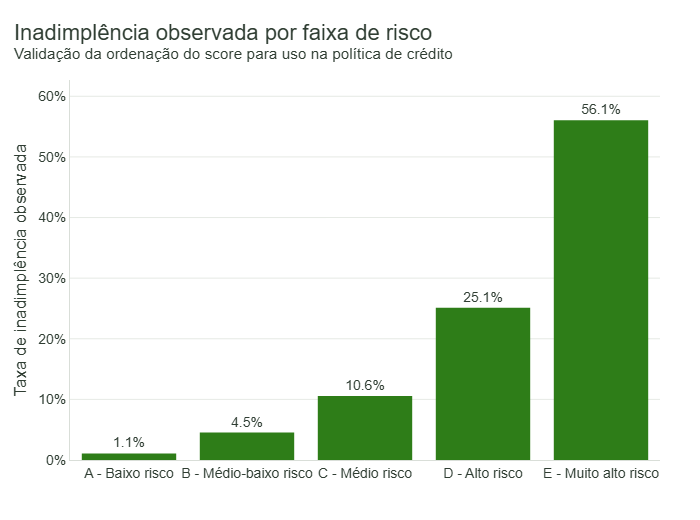

In [11]:
# Gráfico da inadimplência observada por faixa de risco.

plot_faixas = resumo_faixas_risco.copy()
plot_faixas["taxa_inadimplencia_pct"] = plot_faixas["taxa_inadimplencia"] * 100

fig = px.bar(
    plot_faixas,
    x="faixa_risco",
    y="taxa_inadimplencia_pct",
    text="taxa_inadimplencia_pct",
)

fig = aplicar_layout(
    fig,
    titulo="Inadimplência observada por faixa de risco",
    subtitulo="Validação da ordenação do score para uso na política de crédito",
    mostrar_legenda=False,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
)

fig.update_xaxes(title="")
fig.update_yaxes(title="Taxa de inadimplência observada", ticksuffix="%")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "05_inadimplencia_por_faixa_risco.html",
)

## 5. Parâmetros iniciais da política

Aqui eu vou definir parâmetros de capacidade de pagamento por faixa de risco.

A lógica é conservadora: clientes de menor risco podem ter maior comprometimento máximo de renda; clientes de maior risco recebem limites menores ou são direcionados para análise manual/recusa.

In [12]:
parametros_politica = pd.DataFrame([
    {
        "faixa_risco": "A - Baixo risco",
        "pct_max_parcela_renda": 0.35,
        "acao_base": "Aprovar",
    },
    {
        "faixa_risco": "B - Médio-baixo risco",
        "pct_max_parcela_renda": 0.30,
        "acao_base": "Aprovar",
    },
    {
        "faixa_risco": "C - Médio risco",
        "pct_max_parcela_renda": 0.25,
        "acao_base": "Aprovar com limite",
    },
    {
        "faixa_risco": "D - Alto risco",
        "pct_max_parcela_renda": 0.15,
        "acao_base": "Análise manual",
    },
    {
        "faixa_risco": "E - Muito alto risco",
        "pct_max_parcela_renda": 0.00,
        "acao_base": "Recusar",
    },
])

display(parametros_politica)

parametros_politica.to_csv(
    TABLES_DIR / "politica_parametros_faixa_risco.csv",
    index=False,
    encoding="utf-8-sig",
)

,faixa_risco,pct_max_parcela_renda,acao_base
0,A - Baixo risco,0.3500,Aprovar
1,B - Médio-baixo risco,0.3000,Aprovar
2,C - Médio risco,0.2500,Aprovar com limite
3,D - Alto risco,0.1500,Análise manual
4,E - Muito alto risco,0.0000,Recusar


## 6. Cálculo do valor máximo sugerido

A política calcula uma parcela máxima aceitável a partir da renda, da faixa de risco e de redutores por restritivos financeiros e relacionamento.

Aí depois eu converto essa parcela máxima em valor máximo de empréstimo usando a fórmula de valor presente de uma série de parcelas.

In [13]:
def calcular_redutor_restritivos(row):
    """
    Reduz o limite sugerido conforme a intensidade dos restritivos.
    """
    valor_restritivos = row["valor_restritivos"]
    restritivos_sobre_renda = row["restritivos_sobre_renda"]

    if pd.isna(valor_restritivos) or valor_restritivos <= 0:
        return 1.00

    if pd.isna(restritivos_sobre_renda):
        return 0.80

    if restritivos_sobre_renda <= 0.02:
        return 0.95
    elif restritivos_sobre_renda <= 0.05:
        return 0.85
    elif restritivos_sobre_renda <= 0.10:
        return 0.70
    else:
        return 0.50


def calcular_redutor_relacionamento(row):
    """
    Aplica redutor para clientes inativos.
    """
    if row["flag_cliente_ativo"] == 1:
        return 1.00
    else:
        return 0.85


def calcular_valor_presente_parcelas(parcela, taxa, prazo):
    """
    Converte uma parcela máxima em valor máximo de empréstimo.

    Considera taxa mensal e prazo em meses.
    """
    if pd.isna(parcela) or pd.isna(prazo) or parcela <= 0 or prazo <= 0:
        return 0.0

    if pd.isna(taxa) or taxa <= 0:
        return parcela * prazo

    return parcela * ((1 - (1 + taxa) ** (-prazo)) / taxa)


df_politica = df_politica.merge(
    parametros_politica,
    on="faixa_risco",
    how="left",
)

df_politica["redutor_restritivos"] = df_politica.apply(
    calcular_redutor_restritivos,
    axis=1,
)

df_politica["redutor_relacionamento"] = df_politica.apply(
    calcular_redutor_relacionamento,
    axis=1,
)

df_politica["redutor_total"] = (
    df_politica["redutor_restritivos"]
    * df_politica["redutor_relacionamento"]
)

df_politica["parcela_maxima_politica"] = (
    df_politica["valor_renda"]
    * df_politica["pct_max_parcela_renda"]
    * df_politica["redutor_total"]
)

df_politica["valor_maximo_politica"] = df_politica.apply(
    lambda row: calcular_valor_presente_parcelas(
        parcela=row["parcela_maxima_politica"],
        taxa=row["valor_taxa"],
        prazo=row["valor_prazo"],
    ),
    axis=1,
)

display(
    df_politica[
        [
            "id_operacao",
            "faixa_risco",
            "pd_score",
            "valor_emprestado",
            "valor_parcela",
            "valor_renda",
            "comprometimento_renda",
            "valor_restritivos",
            "redutor_total",
            "parcela_maxima_politica",
            "valor_maximo_politica",
            "acao_base",
        ]
    ].head()
)

,id_operacao,faixa_risco,pd_score,valor_emprestado,valor_parcela,valor_renda,comprometimento_renda,valor_restritivos,redutor_total,parcela_maxima_politica,valor_maximo_politica,acao_base
0,25527,B - Médio-baixo risco,0.0486,"17,776.6600","2,391.6500","3,122.0200",0.7661,12.1300,0.9500,889.7757,"6,613.5278",Aprovar
1,20641,A - Baixo risco,0.0233,"16,611.7100","1,847.0300","2,435.6200",0.7583,26.3300,0.9500,809.8436,"7,283.5227",Aprovar
2,5207,B - Médio-baixo risco,0.0735,"3,115.1300",470.8700,"2,733.8700",0.1722,110.5300,0.8500,697.1368,"4,612.0378",Aprovar
3,18223,A - Baixo risco,0.0291,"30,258.8300","2,855.5500","5,426.9400",0.5262,0.0000,1.0000,"1,899.4290","20,127.2925",Aprovar
4,22025,A - Baixo risco,0.0215,"9,520.5300","1,262.2300","1,472.7900",0.8570,44.1000,0.8500,438.1550,"3,304.8382",Aprovar


## 7. Regra final de decisão

Combinando risco e capacidade de pagamento, defino a decisão final da política.

A política diferencia quatro saídas:

- aprovar valor solicitado;
- aprovar valor reduzido;
- enviar para análise manual;
- recusar.

In [14]:
VALOR_MINIMO_OPERACAO = 500


def definir_decisao_politica(row):
    """
    Define a decisão final da política de concessão.
    """
    faixa = row["faixa_risco"]
    valor_solicitado = row["valor_emprestado"]
    valor_maximo = row["valor_maximo_politica"]
    comprometimento = row["comprometimento_renda"]
    restritivos_sobre_renda = row["restritivos_sobre_renda"]

    if faixa == "E - Muito alto risco":
        return "Recusar"

    if faixa == "D - Alto risco":
        if restritivos_sobre_renda > 0.10:
            return "Recusar"
        return "Análise manual"

    if valor_maximo >= valor_solicitado:
        return "Aprovar valor solicitado"

    if valor_maximo >= VALOR_MINIMO_OPERACAO:
        return "Aprovar valor reduzido"

    return "Recusar"


df_politica["decisao_politica"] = df_politica.apply(
    definir_decisao_politica,
    axis=1,
)

df_politica["valor_aprovado_politica"] = np.select(
    [
        df_politica["decisao_politica"] == "Aprovar valor solicitado",
        df_politica["decisao_politica"] == "Aprovar valor reduzido",
    ],
    [
        df_politica["valor_emprestado"],
        np.minimum(
            df_politica["valor_emprestado"],
            df_politica["valor_maximo_politica"],
        ),
    ],
    default=0.0,
)

display(
    df_politica[
        [
            "id_operacao",
            "faixa_risco",
            "pd_score",
            "valor_emprestado",
            "valor_maximo_politica",
            "valor_aprovado_politica",
            "decisao_politica",
            target_col,
        ]
    ].head()
)

,id_operacao,faixa_risco,pd_score,valor_emprestado,valor_maximo_politica,valor_aprovado_politica,decisao_politica,target_inadimplente_12m
0,25527,B - Médio-baixo risco,0.0486,"17,776.6600","6,613.5278","6,613.5278",Aprovar valor reduzido,0.0000
1,20641,A - Baixo risco,0.0233,"16,611.7100","7,283.5227","7,283.5227",Aprovar valor reduzido,0.0000
2,5207,B - Médio-baixo risco,0.0735,"3,115.1300","4,612.0378","3,115.1300",Aprovar valor solicitado,0.0000
3,18223,A - Baixo risco,0.0291,"30,258.8300","20,127.2925","20,127.2925",Aprovar valor reduzido,0.0000
4,22025,A - Baixo risco,0.0215,"9,520.5300","3,304.8382","3,304.8382",Aprovar valor reduzido,0.0000


## 8. Simulação da política na safra de validação

Agora eu comparo a carteira histórica com a política proposta.

Como a base contém apenas operações concedidas, esta simulação deve ser lida como um backtest sobre a carteira aprovada historicamente, não como uma avaliação completa sobre todas as propostas recebidas.

In [15]:
resumo_decisao_politica = (
    df_politica
    .groupby("decisao_politica", as_index=False)
    .agg(
        qtd_operacoes=("id_operacao", "count"),
        taxa_inadimplencia=("target_inadimplente_12m", "mean"),
        pd_media=("pd_score", "mean"),
        valor_total_solicitado=("valor_emprestado", "sum"),
        valor_total_aprovado=("valor_aprovado_politica", "sum"),
        valor_medio_solicitado=("valor_emprestado", "mean"),
        valor_medio_aprovado=("valor_aprovado_politica", "mean"),
    )
)

resumo_decisao_politica["perc_operacoes"] = (
    resumo_decisao_politica["qtd_operacoes"]
    / resumo_decisao_politica["qtd_operacoes"].sum()
)

display(resumo_decisao_politica)

resumo_decisao_politica.to_csv(
    TABLES_DIR / "politica_resumo_decisao.csv",
    index=False,
    encoding="utf-8-sig",
)

,decisao_politica,qtd_operacoes,taxa_inadimplencia,pd_media,valor_total_solicitado,valor_total_aprovado,valor_medio_solicitado,valor_medio_aprovado,perc_operacoes
0,Análise manual,679,0.2533,0.2253,"10,402,036.8700",0.0000,"15,319.6419",0.0000,0.1397
1,Aprovar valor reduzido,2486,0.0515,0.0626,"40,081,521.6400","19,093,368.8639","16,122.8969","7,680.3575",0.5113
2,Aprovar valor solicitado,1158,0.0121,0.0233,"6,323,350.2400","6,323,350.2400","5,460.5788","5,460.5788",0.2382
3,Recusar,539,0.5269,0.4933,"7,797,458.4700",0.0000,"14,466.5278",0.0000,0.1109


In [16]:
# Indicadores executivos da política.

mask_aprovacao_automatica = df_politica["decisao_politica"].isin([
    "Aprovar valor solicitado",
    "Aprovar valor reduzido",
])

df_aprovados = df_politica[mask_aprovacao_automatica].copy()

indicadores_politica = pd.DataFrame([
    {
        "indicador": "Operações históricas na safra",
        "valor": len(df_politica),
    },
    {
        "indicador": "Taxa de inadimplência histórica",
        "valor": df_politica[target_col].mean(),
    },
    {
        "indicador": "Taxa de aprovação automática simulada",
        "valor": mask_aprovacao_automatica.mean(),
    },
    {
        "indicador": "Taxa de inadimplência dos aprovados pela política",
        "valor": df_aprovados[target_col].mean(),
    },
    {
        "indicador": "Valor total emprestado histórico",
        "valor": df_politica["valor_emprestado"].sum(),
    },
    {
        "indicador": "Valor total aprovado pela política",
        "valor": df_politica["valor_aprovado_politica"].sum(),
    },
    {
        "indicador": "Redução simulada de exposição",
        "valor": 1 - (
            df_politica["valor_aprovado_politica"].sum()
            / df_politica["valor_emprestado"].sum()
        ),
    },
])

display(indicadores_politica)

indicadores_politica.to_csv(
    TABLES_DIR / "politica_indicadores_executivos.csv",
    index=False,
    encoding="utf-8-sig",
)

,indicador,valor
0,Operações históricas na safra,"4,862.0000"
1,Taxa de inadimplência histórica,0.1230
2,Taxa de aprovação automática simulada,0.7495
3,Taxa de inadimplência dos aprovados pela política,0.0390
4,Valor total emprestado histórico,"64,604,367.2200"
5,Valor total aprovado pela política,"25,416,719.1039"
6,Redução simulada de exposição,0.6066


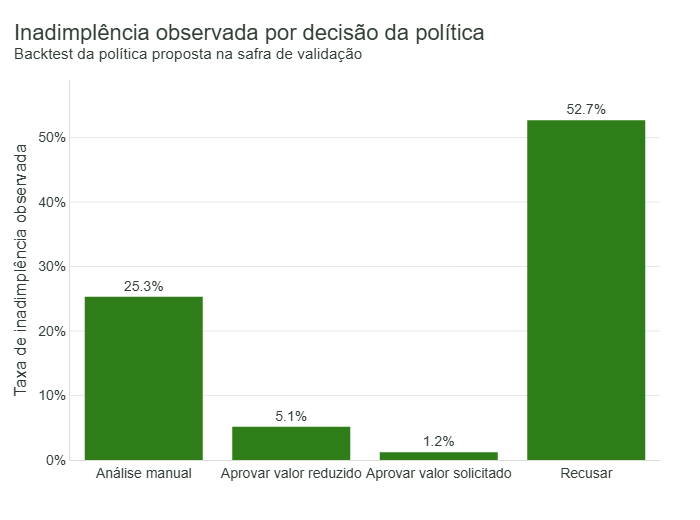

In [17]:
# Gráfico da inadimplência por decisão da política.

plot_decisao = resumo_decisao_politica.copy()
plot_decisao["taxa_inadimplencia_pct"] = (
    plot_decisao["taxa_inadimplencia"] * 100
)

fig = px.bar(
    plot_decisao,
    x="decisao_politica",
    y="taxa_inadimplencia_pct",
    text="taxa_inadimplencia_pct",
)

fig = aplicar_layout(
    fig,
    titulo="Inadimplência observada por decisão da política",
    subtitulo="Backtest da política proposta na safra de validação",
    mostrar_legenda=False,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
)

fig.update_xaxes(title="")
fig.update_yaxes(title="Taxa de inadimplência observada", ticksuffix="%")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "05_inadimplencia_por_decisao_politica.html",
)

## 9. Interpretação do modelo candidato

Antes de fechar a política de concessão, eu vou avaliar se o modelo candidato está usando sinais coerentes com o problema de crédito.

Essa etapa é importante porque a política não deve depender apenas da performance estatística do modelo. Também é necessário verificar se as variáveis que mais influenciam a PD fazem sentido do ponto de vista de concessão, capacidade de pagamento, restritivos financeiros e relacionamento com o banco.

A interpretação será feita por quatro visões:

1. importância global por permutação;
2. importância global via SHAP;
3. direção dos efeitos das principais variáveis numéricas;
4. explicações locais para clientes de baixo, médio e alto risco.

In [ ]:
# Limpeza de objetos antigos da seção de interpretação

#objetos_interpretacao = [
#    "importancia_permutacao",
#    "importancia_shap",
#    "importancia_shap_agregada",
#    "importancia_shap_transformada_top",
#    "analise_faixas_variaveis",
#    "explicacoes_locais",
#    "plot_importancia",
#    "plot_shap",
#    "plot_shap_transformado",
#    "plot_faixas_var",
#    "plot_exp_local",
#]
#
#for objeto in objetos_interpretacao:
#    if objeto in globals():
#        del globals()[objeto]
#
#print("Objetos antigos da interpretação removidos.")

Objetos antigos da interpretação removidos.


In [26]:
# Dicionário padrão para nomes gerenciais das variáveis

nomes_variaveis = {
    "cat_escolaridade": "Escolaridade",
    "comprometimento_renda": "Comprometimento de renda",
    "flag_cliente_ativo": "Cliente ativo",
    "valor_restritivos": "Valor de restritivos",
    "tempo_conta_anos": "Tempo de conta",
    "idade_concessao": "Idade na concessão",
    "restritivos_sobre_renda": "Restritivos / renda",
    "valor_taxa": "Taxa",
    "valor_renda": "Renda",
    "valor_prazo": "Prazo",
    "valor_emprestado": "Valor emprestado",
    "valor_parcela": "Valor da parcela",
}

### 9.1 Importância global por permutation importance

A permutation importance mede quanto a performance do modelo piora quando uma variável é embaralhada.

Essa leitura é útil porque avalia a importância das variáveis diretamente na safra de validação da política, mantendo as variáveis no formato original de negócio.

In [27]:
# Importância global das variáveis originais

X_interpretacao = df_politica[features_modelo].copy()
y_interpretacao = df_politica[target_col].copy()

perm_importance = permutation_importance(
    estimator=modelo_pd,
    X=X_interpretacao,
    y=y_interpretacao,
    scoring="roc_auc",
    n_repeats=10,
    random_state=1995,
    n_jobs=-1,
)

importancia_permutacao = pd.DataFrame({
    "variavel": features_modelo,
    "importancia_media": perm_importance.importances_mean,
    "importancia_desvio": perm_importance.importances_std,
})

importancia_permutacao = (
    importancia_permutacao
    .sort_values("importancia_media", ascending=False)
    .reset_index(drop=True)
)

importancia_permutacao["variavel_exibicao"] = (
    importancia_permutacao["variavel"]
    .replace(nomes_variaveis)
)

display(importancia_permutacao)

importancia_permutacao.to_csv(
    TABLES_DIR / "politica_importancia_permutacao_modelo.csv",
    index=False,
    encoding="utf-8-sig",
)

,variavel,importancia_media,importancia_desvio,variavel_exibicao
0,cat_escolaridade,0.0935,0.0022,Escolaridade
1,comprometimento_renda,0.0893,0.0071,Comprometimento de renda
2,flag_cliente_ativo,0.0551,0.0024,Cliente ativo
3,valor_restritivos,0.0352,0.0031,Valor de restritivos
4,tempo_conta_anos,0.0254,0.0032,Tempo de conta
5,idade_concessao,0.0123,0.0015,Idade na concessão
6,restritivos_sobre_renda,0.0032,0.0011,Restritivos / renda
7,valor_taxa,0.0001,0.0001,Taxa
8,valor_renda,0.0000,0.0002,Renda
9,valor_prazo,-0.0000,0.0001,Prazo


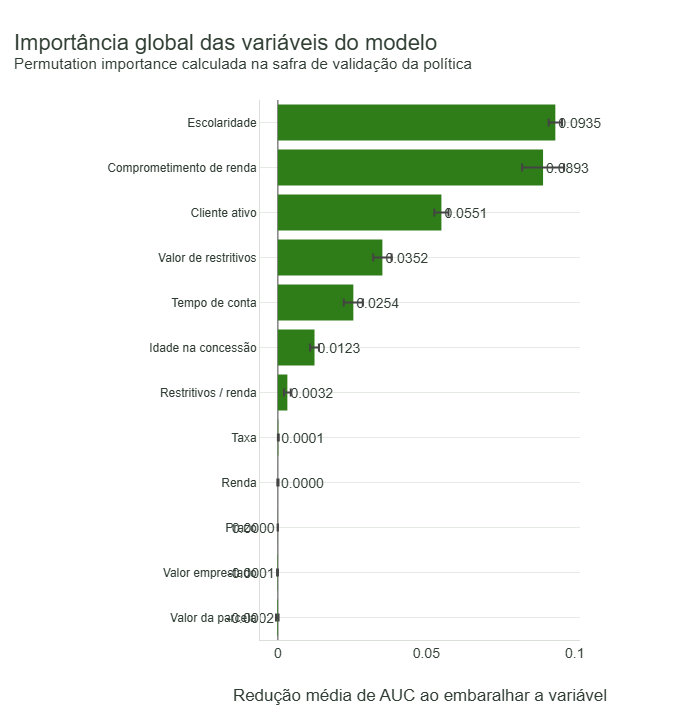

In [ ]:
# Gráfico da importância por permutação

plot_importancia = importancia_permutacao.head(15).copy()
plot_importancia = plot_importancia.sort_values("importancia_media")

fig = px.bar(
    plot_importancia,
    x="importancia_media",
    y="variavel_exibicao",
    orientation="h",
    error_x="importancia_desvio",
    text="importancia_media",
)

fig = aplicar_layout(
    fig,
    titulo="Importância global das variáveis do modelo",
    subtitulo="Permutation importance calculada na safra de validação da política",
    mostrar_legenda=False,
)

fig.update_traces(
    texttemplate="%{text:.4f}",
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    height=max(550, 45 * len(plot_importancia) + 180),
    margin=dict(
        l=280,
        r=150,
        t=105,
        b=90,
    ),
)

fig.update_xaxes(
    title="Redução média de AUC ao embaralhar a variável",
    zeroline=True,
    rangemode="tozero",
)

fig.update_yaxes(
    title="",
    automargin=True,
    tickfont=dict(size=12),
)

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "05_importancia_permutacao_modelo.html",
)

### 9.2 Preparação da base para interpretação via SHAP

Como o modelo candidato está dentro de um pipeline, primeiro eu vou aplicar o mesmo pré-processamento usado na modelagem.

Depois disso, calculo os valores SHAP sobre uma amostra da safra de validação da política. A amostra também inclui três clientes específicos para explicações locais: baixo risco, risco médio e alto risco.

In [28]:
# Seleção de clientes para explicações locais

idx_baixo_risco = df_politica["pd_score"].idxmin()

idx_alto_risco = df_politica["pd_score"].idxmax()

idx_risco_medio = (
    (df_politica["pd_score"] - df_politica["pd_score"].median())
    .abs()
    .idxmin()
)

indices_explicacao = [
    idx_baixo_risco,
    idx_risco_medio,
    idx_alto_risco,
]

rotulos_explicacao = {
    idx_baixo_risco: "Baixo risco",
    idx_risco_medio: "Risco médio",
    idx_alto_risco: "Alto risco",
}

print("Índices selecionados para explicação local:", indices_explicacao)

Índices selecionados para explicação local: [1817, 3080, 2513]


In [30]:
# Preparação da amostra para SHAP

n_amostra_shap = min(2000, len(df_politica))

X_shap_original = (
    df_politica[features_modelo]
    .sample(n=n_amostra_shap, random_state=42)
    .copy()
)

X_explicacao_local = df_politica.loc[
    indices_explicacao,
    features_modelo,
].copy()

# Garante que os clientes das explicações locais estejam na amostra SHAP
X_shap_original = (
    pd.concat([X_shap_original, X_explicacao_local], axis=0)
    .loc[lambda df: ~df.index.duplicated(keep="first")]
)

# Compatibilidade com pipelines nomeados como "preprocessor" ou "preprocessador"
if "preprocessor" in modelo_pd.named_steps:
    nome_step_preprocessador = "preprocessor"
elif "preprocessador" in modelo_pd.named_steps:
    nome_step_preprocessador = "preprocessador"
else:
    raise KeyError(
        f"Não encontrei o step de pré-processamento. "
        f"Steps disponíveis: {list(modelo_pd.named_steps.keys())}"
    )

preprocessador_modelo = modelo_pd.named_steps[nome_step_preprocessador]
classificador_modelo = modelo_pd.named_steps["modelo"]

X_shap_transformado = preprocessador_modelo.transform(X_shap_original)

if hasattr(X_shap_transformado, "toarray"):
    X_shap_transformado = X_shap_transformado.toarray()

nomes_features_transformadas = preprocessador_modelo.get_feature_names_out()

X_shap_transformado = pd.DataFrame(
    X_shap_transformado,
    columns=nomes_features_transformadas,
    index=X_shap_original.index,
)

print("Step de pré-processamento usado:", nome_step_preprocessador)
print("Shape base original SHAP:", X_shap_original.shape)
print("Shape base transformada SHAP:", X_shap_transformado.shape)

Step de pré-processamento usado: preprocessador
Shape base original SHAP: (2002, 12)
Shape base transformada SHAP: (2002, 22)


In [31]:
# Cálculo dos valores SHAP

explainer = shap.TreeExplainer(classificador_modelo)
shap_values = explainer.shap_values(X_shap_transformado)

# Para classificação binária, algumas versões retornam lista por classe.
# A classe 1 representa inadimplência.
if isinstance(shap_values, list):
    shap_values_classe_1 = shap_values[1]
else:
    shap_values_classe_1 = shap_values

# Algumas versões podem retornar matriz 3D: n_amostras x n_features x n_classes
if len(np.array(shap_values_classe_1).shape) == 3:
    shap_values_classe_1 = shap_values_classe_1[:, :, 1]

print("Shape valores SHAP classe 1:", np.array(shap_values_classe_1).shape)

Shape valores SHAP classe 1: (2002, 22)


### 9.3 Importância SHAP agregada por variável original

As variáveis categóricas foram transformadas em dummies no pipeline. Para deixar a leitura mais gerencial, eu agreguei as contribuições SHAP de volta para a variável original.

Assim, as categorias como escolaridade e status de cliente ativo voltam a ser interpretadas como variáveis únicas.

In [32]:
# Função para agrupar features transformadas na variável original

def identificar_variavel_original(nome_feature):
    """
    Agrupa features transformadas de volta para a variável original.
    """
    nome_limpo = (
        nome_feature
        .replace("num__", "")
        .replace("cat__", "")
        .replace("remainder__", "")
    )

    for variavel in features_modelo:
        if nome_limpo == variavel:
            return variavel

        if nome_limpo.startswith(variavel + "_"):
            return variavel

    return nome_limpo

In [33]:
# Importância SHAP por variável transformada e agregada

importancia_shap = pd.DataFrame({
    "variavel_transformada": nomes_features_transformadas,
    "shap_medio_absoluto": np.abs(shap_values_classe_1).mean(axis=0),
})

importancia_shap["variavel_original"] = (
    importancia_shap["variavel_transformada"]
    .apply(identificar_variavel_original)
)

importancia_shap_agregada = (
    importancia_shap
    .groupby("variavel_original", as_index=False)
    .agg(
        shap_medio_absoluto=("shap_medio_absoluto", "sum"),
        qtd_features_transformadas=("variavel_transformada", "count"),
    )
    .sort_values("shap_medio_absoluto", ascending=False)
    .reset_index(drop=True)
)

importancia_shap_agregada["variavel_exibicao"] = (
    importancia_shap_agregada["variavel_original"]
    .replace(nomes_variaveis)
)

display(importancia_shap_agregada)

importancia_shap.to_csv(
    TABLES_DIR / "politica_importancia_shap_variaveis_transformadas.csv",
    index=False,
    encoding="utf-8-sig",
)

importancia_shap_agregada.to_csv(
    TABLES_DIR / "politica_importancia_shap_agregada_modelo.csv",
    index=False,
    encoding="utf-8-sig",
)

,variavel_original,shap_medio_absoluto,qtd_features_transformadas,variavel_exibicao
0,cat_escolaridade,0.8603,10,Escolaridade
1,comprometimento_renda,0.5956,1,Comprometimento de renda
2,valor_restritivos,0.4303,1,Valor de restritivos
3,flag_cliente_ativo,0.3855,2,Cliente ativo
4,tempo_conta_anos,0.2989,1,Tempo de conta
5,idade_concessao,0.1755,1,Idade na concessão
6,restritivos_sobre_renda,0.1569,1,Restritivos / renda
7,valor_parcela,0.0341,1,Valor da parcela
8,valor_emprestado,0.0208,1,Valor emprestado
9,valor_taxa,0.0178,1,Taxa


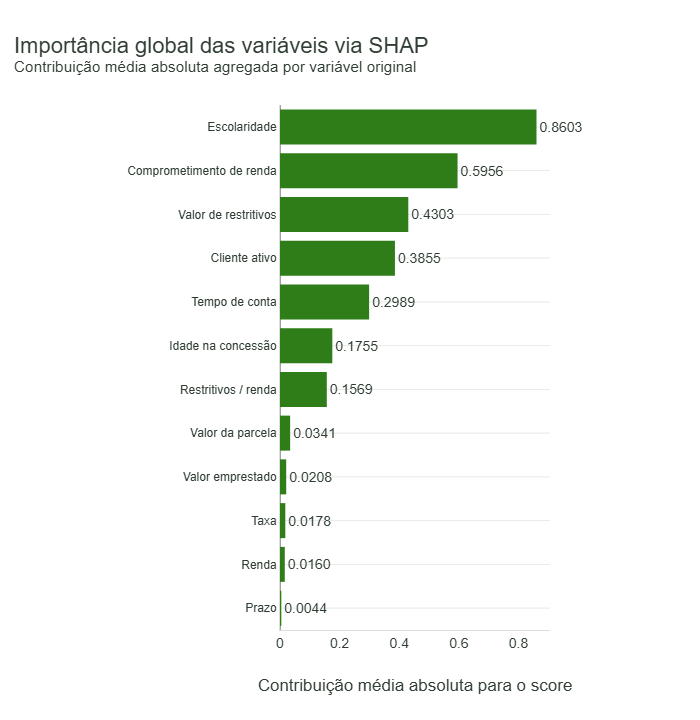

In [34]:
# Gráfico de importância SHAP agregado por variável original

plot_shap = importancia_shap_agregada.head(15).copy()
plot_shap = plot_shap.sort_values("shap_medio_absoluto")

fig = px.bar(
    plot_shap,
    x="shap_medio_absoluto",
    y="variavel_exibicao",
    orientation="h",
    text="shap_medio_absoluto",
)

fig = aplicar_layout(
    fig,
    titulo="Importância global das variáveis via SHAP",
    subtitulo="Contribuição média absoluta agregada por variável original",
    mostrar_legenda=False,
)

fig.update_traces(
    texttemplate="%{text:.4f}",
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    height=max(550, 45 * len(plot_shap) + 180),
    margin=dict(
        l=280,
        r=150,
        t=105,
        b=90,
    ),
)

fig.update_xaxes(
    title="Contribuição média absoluta para o score",
    zeroline=True,
    rangemode="tozero",
)

fig.update_yaxes(
    title="",
    automargin=True,
    tickfont=dict(size=12),
)

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "05_importancia_shap_modelo_agregado.html",
)

### 9.4 Importância SHAP por variável transformada

A visão agregada é melhor para apresentação gerencial. Ainda assim, mantenho uma tabela técnica com as variáveis transformadas para verificar quais categorias específicas mais influenciam o score.

In [35]:
# Tabela técnica com variáveis transformadas mais importantes

importancia_shap_transformada_top = (
    importancia_shap
    .sort_values("shap_medio_absoluto", ascending=False)
    .head(25)
    .copy()
)

display(importancia_shap_transformada_top)

importancia_shap_transformada_top.to_csv(
    TABLES_DIR / "politica_importancia_shap_transformada_top25.csv",
    index=False,
    encoding="utf-8-sig",
)

,variavel_transformada,shap_medio_absoluto,variavel_original
8,num__comprometimento_renda,0.5956,comprometimento_renda
5,num__valor_restritivos,0.4303,valor_restritivos
14,cat__cat_escolaridade_Não Declarado,0.4303,cat_escolaridade
7,num__tempo_conta_anos,0.2989,tempo_conta_anos
17,cat__cat_escolaridade_Sem Escolaridade,0.2774,cat_escolaridade
20,cat__flag_cliente_ativo_0,0.2007,flag_cliente_ativo
21,cat__flag_cliente_ativo_1,0.1848,flag_cliente_ativo
6,num__idade_concessao,0.1755,idade_concessao
9,num__restritivos_sobre_renda,0.1569,restritivos_sobre_renda
11,cat__cat_escolaridade_Fundamental Incompleto,0.0602,cat_escolaridade


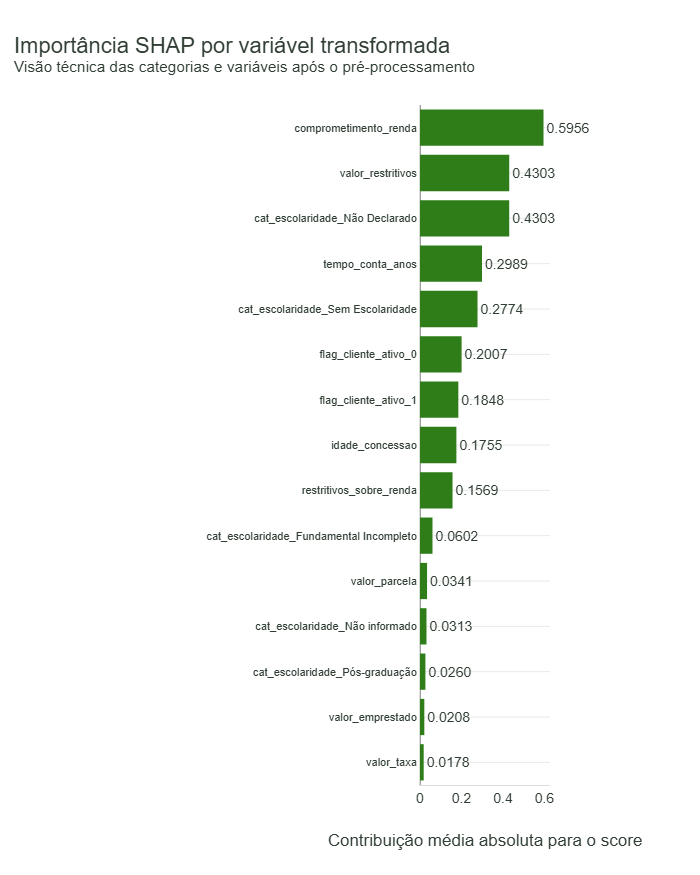

In [36]:
# Gráfico técnico das variáveis transformadas mais importantes

plot_shap_transformado = importancia_shap_transformada_top.head(15).copy()

plot_shap_transformado["variavel_transformada_exibicao"] = (
    plot_shap_transformado["variavel_transformada"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("remainder__", "", regex=False)
)

plot_shap_transformado = plot_shap_transformado.sort_values("shap_medio_absoluto")

fig = px.bar(
    plot_shap_transformado,
    x="shap_medio_absoluto",
    y="variavel_transformada_exibicao",
    orientation="h",
    text="shap_medio_absoluto",
)

fig = aplicar_layout(
    fig,
    titulo="Importância SHAP por variável transformada",
    subtitulo="Visão técnica das categorias e variáveis após o pré-processamento",
    mostrar_legenda=False,
)

fig.update_traces(
    texttemplate="%{text:.4f}",
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    height=max(650, 45 * len(plot_shap_transformado) + 200),
    margin=dict(
        l=420,
        r=150,
        t=105,
        b=90,
    ),
)

fig.update_xaxes(
    title="Contribuição média absoluta para o score",
    zeroline=True,
    rangemode="tozero",
)

fig.update_yaxes(
    title="",
    automargin=True,
    tickfont=dict(size=11),
)

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "05_importancia_shap_variaveis_transformadas.html",
)

### 9.5 Direção dos efeitos das variáveis principais

A importância SHAP mostra quais variáveis mais pesam no modelo, mas não mostra sozinha se valores maiores aumentam ou reduzem o risco.

Por isso, eu vou avaliar a relação entre as principais variáveis numéricas, a PD média prevista e a inadimplência observada.

In [37]:
# Seleciona principais variáveis numéricas pela importância SHAP agregada

top_variaveis_numericas = [
    v for v in importancia_shap_agregada["variavel_original"].tolist()
    if v in features_numericas
][:5]

print("Variáveis numéricas analisadas:", top_variaveis_numericas)

Variáveis numéricas analisadas: ['comprometimento_renda', 'valor_restritivos', 'tempo_conta_anos', 'idade_concessao', 'restritivos_sobre_renda']


In [38]:
# Cria tabela por faixas das principais variáveis numéricas

analise_faixas_variaveis = []

for variavel in top_variaveis_numericas:
    temp = df_politica[[variavel, target_col, "pd_score"]].copy()
    temp = temp.dropna(subset=[variavel])

    temp["faixa_variavel"] = pd.qcut(
        temp[variavel].rank(method="first"),
        q=5,
        duplicates="drop",
    )

    resumo_temp = (
        temp
        .groupby("faixa_variavel", observed=True)
        .agg(
            qtd_clientes=(target_col, "size"),
            valor_min=(variavel, "min"),
            valor_max=(variavel, "max"),
            valor_medio=(variavel, "mean"),
            pd_media=("pd_score", "mean"),
            taxa_inadimplencia=(target_col, "mean"),
        )
        .reset_index()
    )

    resumo_temp["variavel"] = variavel
    resumo_temp["variavel_exibicao"] = nomes_variaveis.get(variavel, variavel)

    analise_faixas_variaveis.append(resumo_temp)

analise_faixas_variaveis = pd.concat(
    analise_faixas_variaveis,
    ignore_index=True,
)

display(analise_faixas_variaveis)

analise_faixas_variaveis.to_csv(
    TABLES_DIR / "politica_analise_faixas_variaveis_modelo.csv",
    index=False,
    encoding="utf-8-sig",
)

,faixa_variavel,qtd_clientes,valor_min,valor_max,valor_medio,pd_media,taxa_inadimplencia,variavel,variavel_exibicao
0,"(0.999, 973.2]",973,0.1002,0.2543,0.1798,0.0279,0.0164,comprometimento_renda,Comprometimento de renda
1,"(973.2, 1945.4]",972,0.2544,0.4169,0.3352,0.1206,0.1265,comprometimento_renda,Comprometimento de renda
2,"(1945.4, 2917.6]",972,0.4170,0.5826,0.5008,0.1594,0.1512,comprometimento_renda,Comprometimento de renda
3,"(2917.6, 3889.8]",972,0.5826,0.7335,0.6570,0.1488,0.1595,comprometimento_renda,Comprometimento de renda
4,"(3889.8, 4862.0]",973,0.7339,0.8996,0.8158,0.1619,0.1614,comprometimento_renda,Comprometimento de renda
5,"(0.999, 973.2]",973,0.0000,0.0000,0.0000,0.0734,0.0637,valor_restritivos,Valor de restritivos
6,"(973.2, 1945.4]",972,0.0000,5.0300,0.3311,0.0781,0.0741,valor_restritivos,Valor de restritivos
7,"(1945.4, 2917.6]",972,5.0400,41.7300,22.9147,0.0768,0.0823,valor_restritivos,Valor de restritivos
8,"(2917.6, 3889.8]",972,41.8000,104.9100,70.0588,0.1707,0.1677,valor_restritivos,Valor de restritivos
9,"(3889.8, 4862.0]",973,104.9200,956.1100,201.8902,0.2193,0.2271,valor_restritivos,Valor de restritivos


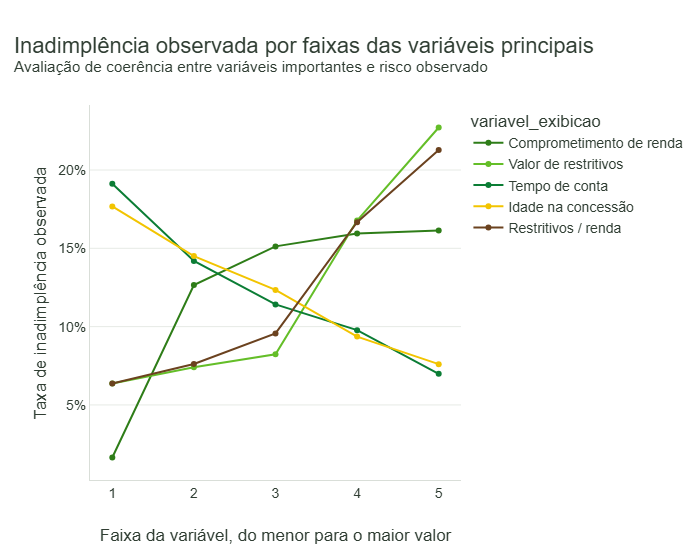

In [39]:
# Gráfico: inadimplência observada por faixas das variáveis principais

plot_faixas_var = analise_faixas_variaveis.copy()

plot_faixas_var["faixa_ordem"] = (
    plot_faixas_var
    .groupby("variavel")
    .cumcount() + 1
)

plot_faixas_var["taxa_inadimplencia_pct"] = (
    plot_faixas_var["taxa_inadimplencia"] * 100
)

fig = px.line(
    plot_faixas_var,
    x="faixa_ordem",
    y="taxa_inadimplencia_pct",
    color="variavel_exibicao",
    markers=True,
)

fig = aplicar_layout(
    fig,
    titulo="Inadimplência observada por faixas das variáveis principais",
    subtitulo="Avaliação de coerência entre variáveis importantes e risco observado",
    mostrar_legenda=True,
)

fig.update_layout(
    height=560,
    margin=dict(
        l=90,
        r=60,
        t=105,
        b=80,
    ),
)

fig.update_xaxes(
    title="Faixa da variável, do menor para o maior valor",
    tickmode="linear",
    dtick=1,
)

fig.update_yaxes(
    title="Taxa de inadimplência observada",
    ticksuffix="%",
)

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "05_inadimplencia_por_faixas_variaveis_modelo.html",
)

### 9.6 Explicações locais de clientes selecionados

Além da interpretação global, eu vou avaliar exemplos individuais de clientes de baixo, médio e alto risco.

Essa análise vai me ajudr a verificar se as decisões do modelo são coerentes em casos concretos.

In [40]:
# Explicações locais com SHAP para clientes selecionados

explicacoes_locais = []

for idx in indices_explicacao:
    posicao = X_shap_transformado.index.get_loc(idx)

    contrib_temp = pd.DataFrame({
        "variavel_transformada": nomes_features_transformadas,
        "valor_transformado": X_shap_transformado.loc[idx].values,
        "contribuicao_shap": shap_values_classe_1[posicao],
    })

    contrib_temp["variavel_original"] = (
        contrib_temp["variavel_transformada"]
        .apply(identificar_variavel_original)
    )

    contrib_temp["variavel_exibicao"] = (
        contrib_temp["variavel_original"]
        .replace(nomes_variaveis)
    )

    contrib_temp["abs_contribuicao"] = (
        contrib_temp["contribuicao_shap"].abs()
    )

    contrib_temp = (
        contrib_temp
        .sort_values("abs_contribuicao", ascending=False)
        .head(10)
    )

    contrib_temp["perfil"] = rotulos_explicacao[idx]
    contrib_temp["id_operacao"] = df_politica.loc[idx, "id_operacao"]
    contrib_temp["pd_score"] = df_politica.loc[idx, "pd_score"]
    contrib_temp["inadimplente_observado"] = df_politica.loc[idx, target_col]
    contrib_temp["faixa_risco"] = df_politica.loc[idx, "faixa_risco"]
    contrib_temp["decisao_politica"] = df_politica.loc[idx, "decisao_politica"]

    explicacoes_locais.append(contrib_temp)

explicacoes_locais = pd.concat(
    explicacoes_locais,
    ignore_index=True,
)

cols_explicacao = [
    "perfil",
    "id_operacao",
    "pd_score",
    "faixa_risco",
    "decisao_politica",
    "inadimplente_observado",
    "variavel_exibicao",
    "variavel_transformada",
    "valor_transformado",
    "contribuicao_shap",
]

display(explicacoes_locais[cols_explicacao])

explicacoes_locais.to_csv(
    TABLES_DIR / "politica_explicacoes_locais_shap.csv",
    index=False,
    encoding="utf-8-sig",
)

,perfil,id_operacao,pd_score,faixa_risco,decisao_politica,inadimplente_observado,variavel_exibicao,variavel_transformada,valor_transformado,contribuicao_shap
0,Baixo risco,2857,0.0047,A - Baixo risco,Aprovar valor solicitado,0.0000,Comprometimento de renda,num__comprometimento_renda,-1.2808,-0.9310
1,Baixo risco,2857,0.0047,A - Baixo risco,Aprovar valor solicitado,0.0000,Tempo de conta,num__tempo_conta_anos,1.8480,-0.3429
2,Baixo risco,2857,0.0047,A - Baixo risco,Aprovar valor solicitado,0.0000,Escolaridade,cat__cat_escolaridade_Pós-graduação,1.0000,-0.3222
3,Baixo risco,2857,0.0047,A - Baixo risco,Aprovar valor solicitado,0.0000,Valor de restritivos,num__valor_restritivos,-0.6600,-0.2537
4,Baixo risco,2857,0.0047,A - Baixo risco,Aprovar valor solicitado,0.0000,Idade na concessão,num__idade_concessao,3.5412,-0.2319
5,Baixo risco,2857,0.0047,A - Baixo risco,Aprovar valor solicitado,0.0000,Escolaridade,cat__cat_escolaridade_Não Declarado,0.0000,-0.2137
6,Baixo risco,2857,0.0047,A - Baixo risco,Aprovar valor solicitado,0.0000,Escolaridade,cat__cat_escolaridade_Sem Escolaridade,0.0000,-0.1429
7,Baixo risco,2857,0.0047,A - Baixo risco,Aprovar valor solicitado,0.0000,Restritivos / renda,num__restritivos_sobre_renda,-0.5656,-0.1189
8,Baixo risco,2857,0.0047,A - Baixo risco,Aprovar valor solicitado,0.0000,Cliente ativo,cat__flag_cliente_ativo_0,0.0000,-0.0944
9,Baixo risco,2857,0.0047,A - Baixo risco,Aprovar valor solicitado,0.0000,Cliente ativo,cat__flag_cliente_ativo_1,1.0000,-0.0916


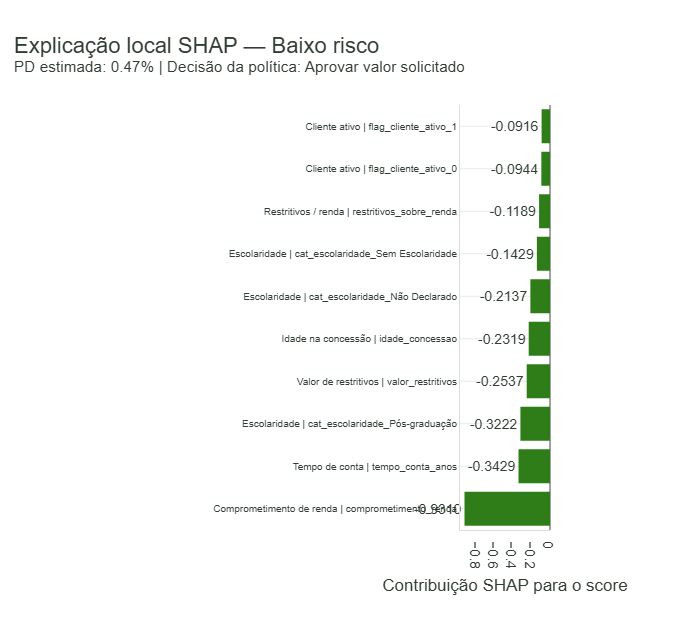

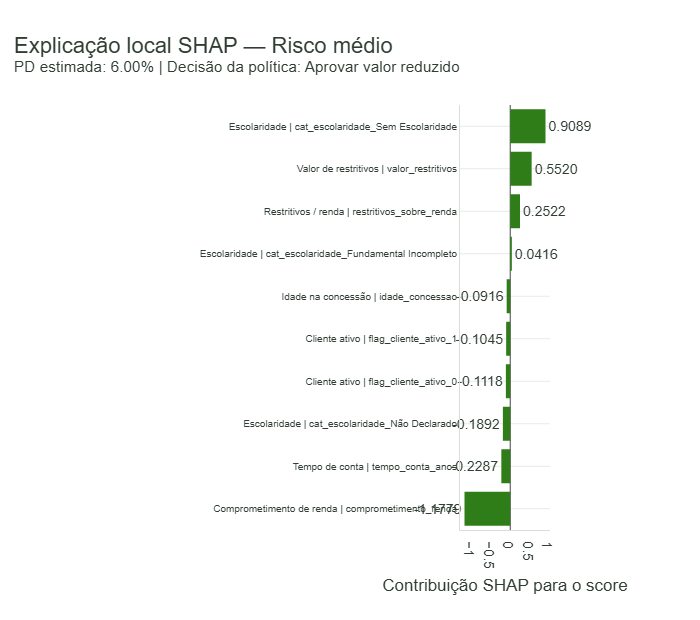

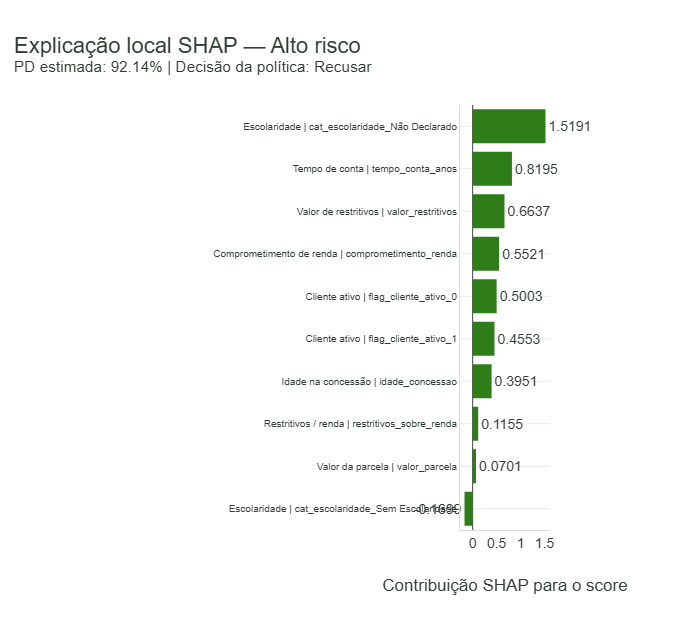

In [41]:
# Gráfico das explicações locais

plot_exp_local = explicacoes_locais.copy()

plot_exp_local["variavel_grafico"] = (
    plot_exp_local["variavel_exibicao"]
    + " | "
    + plot_exp_local["variavel_transformada"]
        .str.replace("num__", "", regex=False)
        .str.replace("cat__", "", regex=False)
        .str.replace("remainder__", "", regex=False)
)

for perfil in ["Baixo risco", "Risco médio", "Alto risco"]:
    temp_plot = (
        plot_exp_local[plot_exp_local["perfil"] == perfil]
        .sort_values("contribuicao_shap")
        .copy()
    )

    fig = px.bar(
        temp_plot,
        x="contribuicao_shap",
        y="variavel_grafico",
        orientation="h",
        text="contribuicao_shap",
    )

    pd_perfil = temp_plot["pd_score"].iloc[0]
    decisao_perfil = temp_plot["decisao_politica"].iloc[0]

    fig = aplicar_layout(
        fig,
        titulo=f"Explicação local SHAP — {perfil}",
        subtitulo=f"PD estimada: {pd_perfil:.2%} | Decisão da política: {decisao_perfil}",
        mostrar_legenda=False,
    )

    fig.update_traces(
        texttemplate="%{text:.4f}",
        textposition="outside",
        cliponaxis=False,
    )

    fig.update_layout(
        height=620,
        margin=dict(
            l=460,
            r=150,
            t=105,
            b=90,
        ),
    )

    fig.update_xaxes(
        title="Contribuição SHAP para o score",
        zeroline=True,
    )

    fig.update_yaxes(
        title="",
        automargin=True,
        tickfont=dict(size=10),
    )

    fig.show()

    nome_arquivo = (
        perfil.lower()
        .replace(" ", "_")
        .replace("é", "e")
        .replace("í", "i")
        .replace("á", "a")
    )

    salvar_figura(
        fig,
        caminho_html=FIGURES_DIR / f"05_explicacao_local_shap_{nome_arquivo}.html",
    )

### 9.7 Resumo executivo da interpretação

Agora eu vou consolidar os principais achados da interpretação do modelo para apoiar na defesa da política de crédito.

In [42]:
# Resumo executivo da interpretação do modelo

top_5_shap = (
    importancia_shap_agregada
    .head(5)["variavel_exibicao"]
    .tolist()
)

top_5_perm = (
    importancia_permutacao
    .head(5)["variavel_exibicao"]
    .tolist()
)

resumo_interpretacao_modelo = pd.DataFrame([
    {
        "evidencia": "Principais variáveis por SHAP",
        "resultado": ", ".join(top_5_shap),
        "interpretacao": "Mostra quais variáveis mais contribuem para o score de risco."
    },
    {
        "evidencia": "Principais variáveis por permutation importance",
        "resultado": ", ".join(top_5_perm),
        "interpretacao": "Mostra quais variáveis mais impactam a AUC quando são embaralhadas."
    },
    {
        "evidencia": "Coerência com política de crédito",
        "resultado": "Variáveis ligadas a renda, comprometimento, restritivos, relacionamento e perfil cadastral aparecem entre os principais sinais.",
        "interpretacao": "O modelo está apoiado em fatores compatíveis com análise de concessão."
    },
    {
        "evidencia": "Uso recomendado",
        "resultado": "Usar a PD como insumo de faixas de decisão, não como regra binária única.",
        "interpretacao": "A política deve combinar score, capacidade de pagamento e restritivos."
    },
])

display(resumo_interpretacao_modelo)

resumo_interpretacao_modelo.to_csv(
    TABLES_DIR / "politica_resumo_interpretacao_modelo.csv",
    index=False,
    encoding="utf-8-sig",
)

,evidencia,resultado,interpretacao
0,Principais variáveis por SHAP,"Escolaridade, Comprometimento de renda, Valor ...",Mostra quais variáveis mais contribuem para o ...
1,Principais variáveis por permutation importance,"Escolaridade, Comprometimento de renda, Client...",Mostra quais variáveis mais impactam a AUC qua...
2,Coerência com política de crédito,"Variáveis ligadas a renda, comprometimento, re...",O modelo está apoiado em fatores compatíveis c...
3,Uso recomendado,"Usar a PD como insumo de faixas de decisão, nã...","A política deve combinar score, capacidade de ..."
